In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("B.8 Unemployment Rate.xlsx", header = 3)
df

,Month,Rate %,Month.1,Rate %.1,Month.2,Rate %.2,Month.3,Rate %.3,Month.4,Rate %.4,Month.5,Rate %.5
0,1963-01-01,6.8,1970-01-01,3.8,1977-01-01,7.9,1984-01-01,8.9,1991-01-01,7.0,1998-01-01,5.0
1,1963-02-01,6.8,1970-02-01,4.3,1977-02-01,8.2,1984-02-01,8.5,1991-02-01,7.4,1998-02-01,4.8
2,1963-03-01,6.2,1970-03-01,4.2,1977-03-01,7.6,1984-03-01,8.3,1991-03-01,7.1,1998-03-01,4.8
3,1963-04-01,5.6,1970-04-01,4.1,1977-04-01,6.7,1984-04-01,7.8,1991-04-01,6.6,1998-04-01,4.0
4,1963-05-01,5.4,1970-05-01,4.2,1977-05-01,6.4,1984-05-01,7.4,1991-05-01,6.7,1998-05-01,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...
79,1969-08-01,3.1,1976-08-01,7.3,1983-08-01,9.4,1990-08-01,5.2,1997-08-01,4.6,2004-08-01,5.3
80,1969-09-01,3.0,1976-09-01,6.9,1983-09-01,8.8,1990-09-01,5.3,1997-09-01,4.5,2004-09-01,5.1
81,1969-10-01,2.8,1976-10-01,6.7,1983-10-01,8.4,1990-10-01,5.2,1997-10-01,4.2,2004-10-01,5.0
82,1969-11-01,2.7,1976-11-01,7.0,1983-11-01,8.2,1990-11-01,5.7,1997-11-01,4.1,2004-11-01,5.1


In [11]:
series = df.iloc[:,[1,3,5,7,9,11]]#but this is not a serie it has 2 dimension now we have to reshape it to 1 dimension
series_numpy = series.values
series_1d = series_numpy.reshape(-1)

In [23]:
#a-)Use simple exponential smoothing with the optimum value of 𝜆 to smooth the
#data (you can find the optimum value from either Minitab or JMP). How well does this
#smoothing procedure work? Compare the results with those obtained in Exercise 4.23.
Simple_Exp_Smoothing = SimpleExpSmoothing(series_1d , initialization_method  = "Estimated")
model_ses = Simple_Exp_Smoothing.fit()
optimal_lambda = model_ses.params["smoothing_level"]
print(f"optimal value:{optimal_lambda}")

optimal value:0.9999999850988388


In [27]:
#c-) Use an exponential smoothing procedure for trends on this data. Is this an
#apparent improvement over the use of simple exponential smoothing with the optimum
#smoothing constant?
Exponential_Smoothing = ExponentialSmoothing(series_1d , trend = "add",seasonal = None , initialization_method="estimated")
model_es = Exponential_Smoothing.fit()
optimum_smoothing_constant = model_es.params["smoothing_level"]
print(f"optimum smoothing constant:{optimum_smoothing_constant}")



optimum smoothing constant:0.9999999850988388


In [35]:
#d-) Take the first difference of this data and plot the time series of first
#differences. Use exponential smoothing on the first differences. Is this a reasonable
#procedure for forecasting the first differences?
series_diff = series_1d.diff()
series_diff_clean = series_diff.dropna() #first value was NaN from the differentiation

<Axes: xlabel='Month', ylabel='Oran %'>

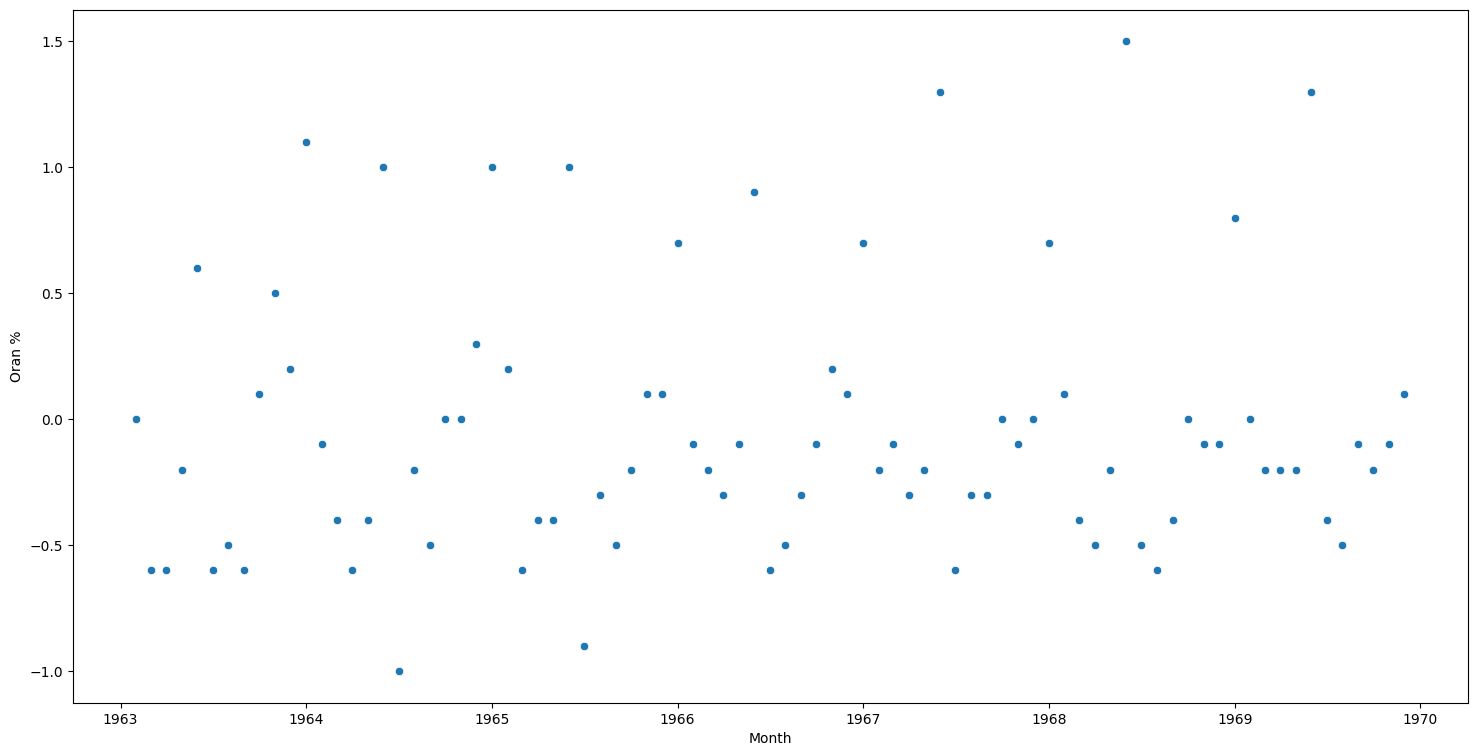

In [43]:
plt.figure(figsize=(18,9))
sns.scatterplot(data = df , x  = df["Month"] , y = series_diff_clean)